# Bit-Controlled Analog Output with Digilent Waveforms (pydwf)

✅ **Purpose**:  
This notebook configures the Digilent Analog Discovery (via the `pydwf` Python package) to output a DC voltage on **Wavegen Channel 1** (Analog Out) according to a provided bit string.

- For each bit in the string:
  - If the bit is `1`, output `1.0V`.
  - If the bit is `0`, output `0.0V`.
- Each output is held for exactly **1 second**.
- At the end, the output is reset to `0.0V`.

> Requires: Digilent Waveforms SDK installed and the `pydwf` package


In [24]:
import time
from pydwf import DwfLibrary, DwfAnalogOutNode, DwfAnalogOutFunction
from pydwf.utilities import openDwfDevice

# Import the function from your module
from dwf_funcs import create_figure, output_bitstream, ScanType
from PIL import Image
import numpy as np
import os

In [2]:
%matplotlib inline

In [25]:
def encode_bw_image(image: Image.Image) -> str:
    """
    Encode a black-and-white image into a bitstring.
    
    Parameters
    ----------
    image : PIL.Image.Image
        Input image. Must be in mode 'L' (grayscale) or '1' (1-bit).

    Returns
    -------
    bitstring : str
        A string of '1's and '0's, row-major flattened. '1' = black, '0' = white.
    """
    # Convert image to grayscale if not already
    if image.mode != 'L':
        image = image.convert('L')  # 8-bit pixels, black and white

    # Threshold to binary: 1 = black (pixel < 128), 0 = white (pixel ≥ 128)
    binary_array = np.array(image) < 128

    # Flatten row-major and convert to bitstring
    bitstring = ''.join(['1' if pixel else '0' for pixel in binary_array.flatten()])

    return bitstring


In [26]:
img = Image.open("creeper_10x10_bw.png")  # black & white square PNG
init_stream = encode_bw_image(img)


preamble = '0' * int(5 / 0.1) + '1'

# Concatenate
bitstream = preamble + init_stream

# Save if file doesn't already exist
filename = "transmission_bitstream.txt"
if not os.path.exists(filename):
    with open(filename, "w") as f:
        f.write(bitstream)
    print(f"Bitstream saved to {filename}")
else:
    print(f"File {filename} already exists — not overwritten.")

# Preview first 64 bits
print("Bitstream preview:", bitstream)

File transmission_bitstream.txt already exists — not overwritten.
Bitstream preview: 0000000000000000000000000000000000000000000000000010010000100011100111011111111110111001110001011010000111111000011111100111111111100110011000010000100


In [27]:
# Define your bitstream and voltage parameters
voltage_high = 4.0         # voltage level for LED ON
voltage_low = 0.0          # voltage level for LED OFF
hold_time = 0.1            # seconds to hold each bit
record_length_time = 10.0

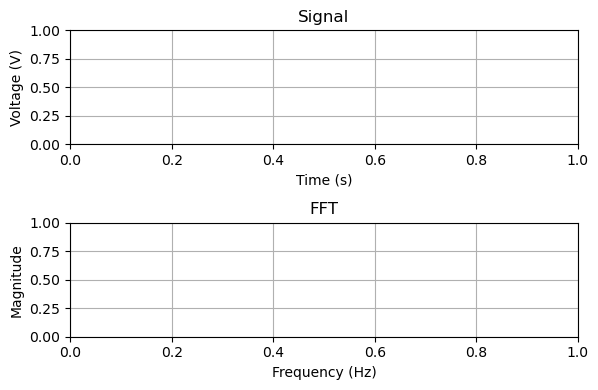

In [28]:
# %%
# Create a TEST figure (time + FFT)
fig, axs = create_figure(ScanType.TEST, figsize=(6, 4))


11111111111111111111111111111111111111111111111111


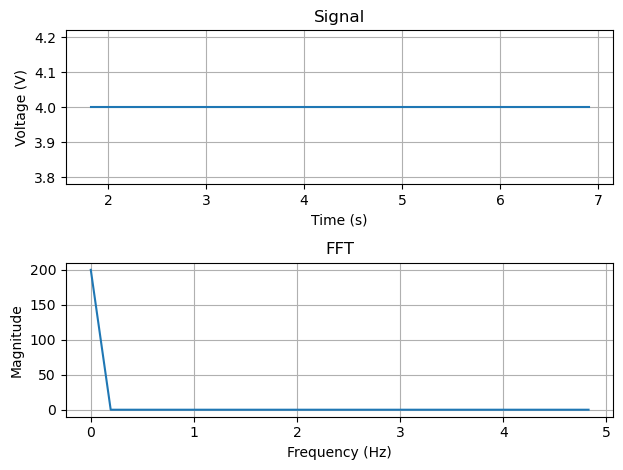

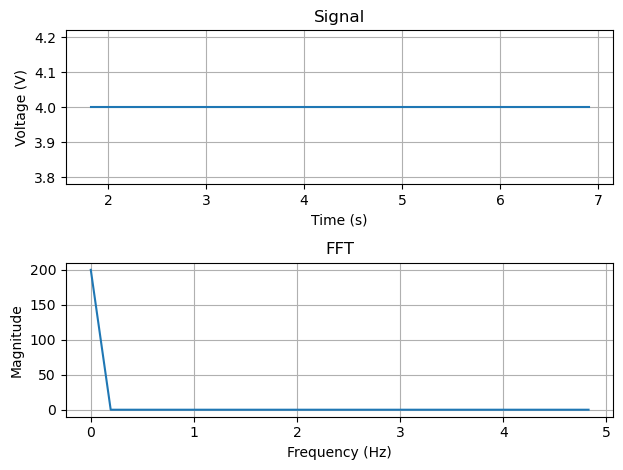

In [31]:
test = '1' * int(5/0.1) 
print(test)
fig2, axs2 = output_bitstream(
    bit_string=test,
    voltage_high=voltage_high,
    voltage_low=voltage_low,
    hold_time=hold_time,
    #record_length_time=record_length_time
)

fig2